<a href="https://colab.research.google.com/github/devarshshah270406-arch/ITA/blob/main/Assignment%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install kaggle
!pip install kaggle

# Upload kaggle.json file
from google.colab import files
files.upload()

# Configure kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d mlg-ulb/creditcardfraud

# Unzip dataset
!unzip creditcardfraud.zip

KeyboardInterrupt: 

# Task
Load the "creditcard.csv" dataset, display its shape and the distribution of the 'Class' variable, and visualize the fraud vs non-fraud transactions.

## Load and Explore Dataset

### Subtask:
Load the 'creditcard.csv' dataset using pandas. Display its shape (number of rows and columns) and show the distribution of the target variable (Class) to understand the class imbalance. Visualize the fraud vs non-fraud transactions using a bar chart, ensuring clear labels and a legend.


**Reasoning**:
Load the 'creditcard.csv' dataset, display its shape, show the distribution of the 'Class' variable, and visualize this distribution with a bar chart as instructed.



Shape of the DataFrame: (284807, 31)

Distribution of the Class variable:
Class
0    284315
1       492
Name: count, dtype: int64


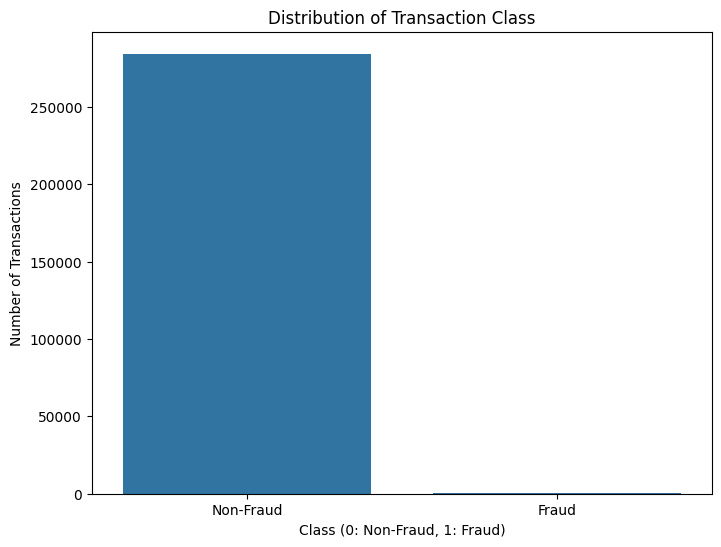

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/creditcard.csv')

# Display the shape of the DataFrame
print('Shape of the DataFrame:', df.shape)

# Display the distribution of the 'Class' variable
print('\nDistribution of the Class variable:')
print(df['Class'].value_counts())

# Visualize the distribution of the 'Class' variable
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df)
plt.title('Distribution of Transaction Class')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Non-Fraud', 'Fraud'])
plt.show()

## Data Preprocessing

### Subtask:
Separate the features (X) from the target variable (y). Apply StandardScaler to normalize the 'Amount' and 'Time' columns, as these are typically on different scales than other features. Finally, display a correlation heatmap of the preprocessed features to identify any strong correlations between variables, making sure the plot is clear and has a legend.


**Reasoning**:
The subtask requires separating features (X) and target (y), scaling specific features ('Amount' and 'Time') using `StandardScaler`, and then visualizing the correlation matrix of the preprocessed features using a heatmap. This code block will perform all these steps.



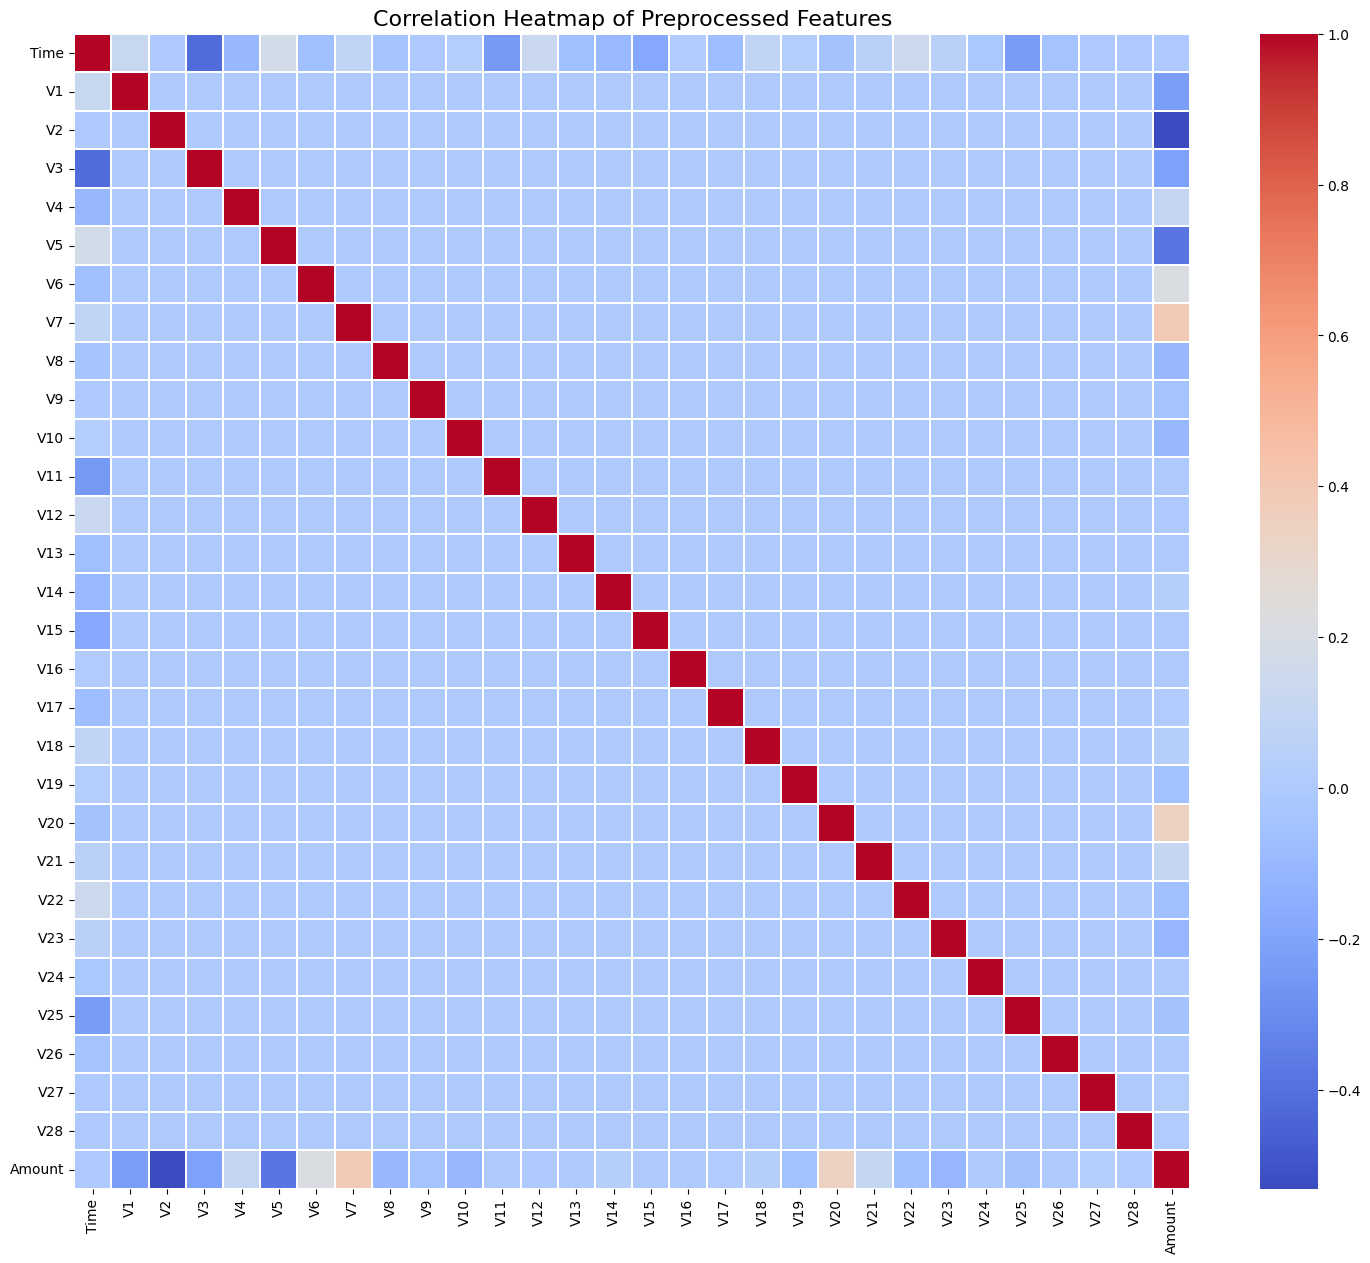

In [3]:
from sklearn.preprocessing import StandardScaler

# 1. Separate features (X) and target variable (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Create a new instance of StandardScaler
scaler = StandardScaler()

# 3. Apply the scaler to 'Amount' and 'Time' columns
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

# 4. Calculate the correlation matrix for all features in the preprocessed X DataFrame
correlation_matrix = X.corr()

# 5. Create a heatmap of the correlation matrix
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.05)
plt.title('Correlation Heatmap of Preprocessed Features', fontsize=16)
plt.show()

## Handle Class Imbalance with SMOTE

### Subtask:
Address the class imbalance using the Synthetic Minority Over-sampling Technique (SMOTE). First, show the class distribution of the target variable before applying SMOTE with a clear bar chart. Then, apply SMOTE to the training data to balance the classes and display the new class distribution with another bar chart, both with appropriate labels and legends.


**Reasoning**:
The subtask requires visualizing the class distribution before SMOTE, applying SMOTE to balance the classes, and then visualizing the class distribution after SMOTE. This code block will perform all these steps.



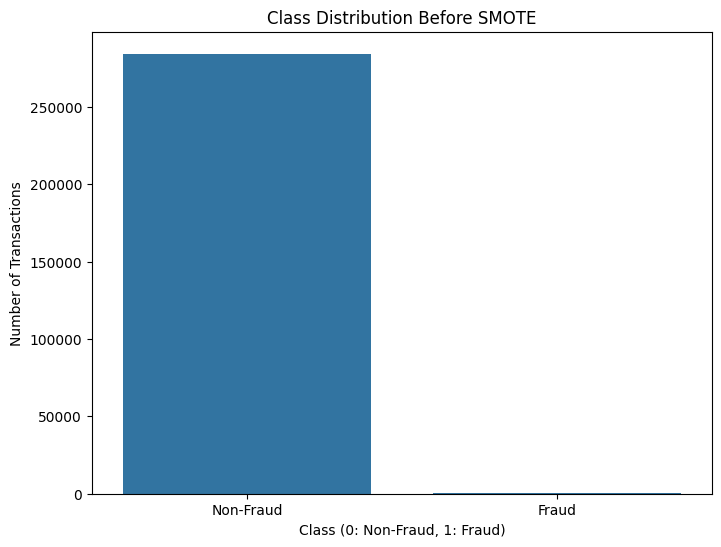

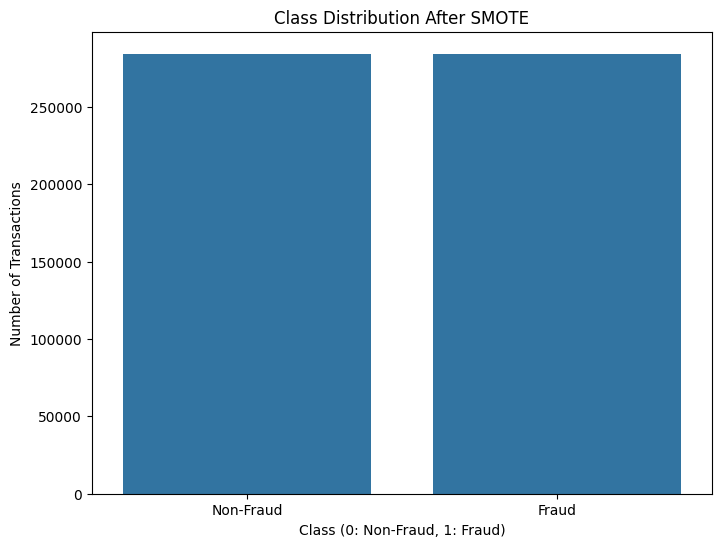

Shape of X_resampled: (568630, 30)
Distribution of Class in y_resampled:
Class
0    284315
1    284315
Name: count, dtype: int64


In [4]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize class distribution before SMOTE
plt.figure(figsize=(8, 6))
sns.countplot(x=y)
plt.title('Class Distribution Before SMOTE')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Non-Fraud', 'Fraud'])
plt.show()

# Apply SMOTE
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)

# Visualize class distribution after SMOTE
plt.figure(figsize=(8, 6))
sns.countplot(x=y_resampled)
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Non-Fraud', 'Fraud'])
plt.show()

print("Shape of X_resampled:", X_resampled.shape)
print("Distribution of Class in y_resampled:")
print(y_resampled.value_counts())

## Unsupervised Anomaly Detection (Isolation Forest)

### Subtask:
Train an Isolation Forest model on the dataset to identify potential anomalies. Generate anomaly scores for each transaction. Add these 'anomaly_score' as a new feature to the dataset. Plot the distribution of these anomaly scores using a histogram or density plot, with clear labels and a legend, to understand their spread.


**Reasoning**:
The subtask requires training an Isolation Forest model, generating anomaly scores, adding them to a DataFrame, and then visualizing the distribution of these scores. This code block will perform all these steps by importing `IsolationForest`, fitting the model, calculating scores, adding them to `X_resampled`, and plotting their distribution.



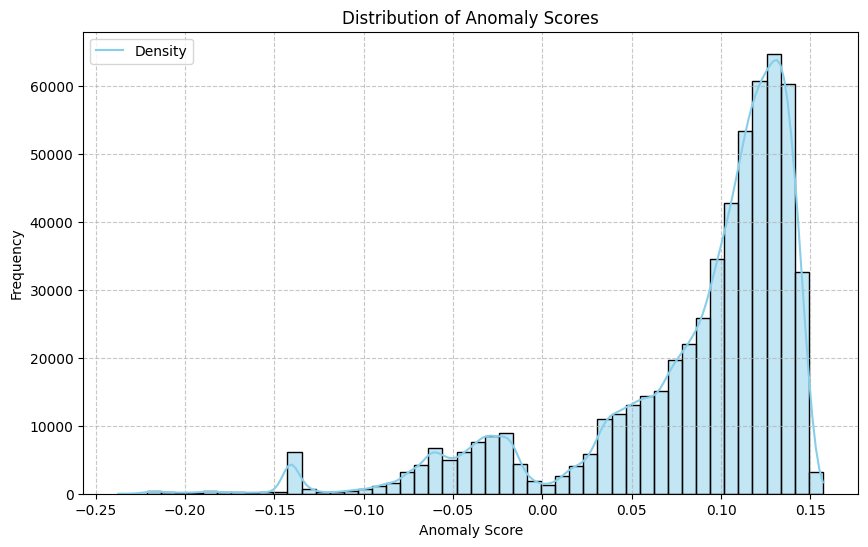

First 5 rows of X_with_scores with anomaly scores:
       Time        V1        V2        V3        V4        V5        V6  \
0 -1.996583 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388   
1 -1.996583  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361   
2 -1.996562 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499   
3 -1.996562 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4 -1.996541 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921   

         V7        V8        V9  ...       V21       V22       V23       V24  \
0  0.239599  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928   
1 -0.078803  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846   
2  0.791461  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281   
3  0.237609  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575   
4  0.592941 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267   

        V25      

In [5]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Instantiate an IsolationForest model
# Set contamination='auto' to let the algorithm estimate the best threshold.
# Alternatively, a specific value (e.g., contamination=0.01) can be used if known.
iso_forest = IsolationForest(random_state=42, contamination='auto')

# 2. Fit the Isolation Forest model to X_resampled
iso_forest.fit(X_resampled)

# 3. Generate anomaly scores using the decision_function()
anomaly_scores = iso_forest.decision_function(X_resampled)

# 4. Add 'anomaly_score' as a new feature to a copy of the dataset
X_with_scores = X_resampled.copy()
X_with_scores['anomaly_score'] = anomaly_scores

# 5. Plot the distribution of anomaly scores
plt.figure(figsize=(10, 6))
sns.histplot(X_with_scores['anomaly_score'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.legend(['Density']) # Add a legend for the KDE
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("First 5 rows of X_with_scores with anomaly scores:")
print(X_with_scores.head())

## Train Supervised Models (Pure)

### Subtask:
Split the preprocessed and SMOTE-handled data into training and testing sets. Train three different supervised machine learning models: Logistic Regression, Random Forest, and Gradient Boosting. These models will be trained on the features without the added 'anomaly_score' to establish a baseline performance.


**Reasoning**:
The subtask requires splitting the data into training and testing sets, and then training three supervised machine learning models: Logistic Regression, Random Forest, and Gradient Boosting. This code block will perform all these steps as instructed.



In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 1. Split the data into training and testing sets
# Note: We are using X_resampled and y_resampled which are SMOTE-handled
X_train_pure, X_test_pure, y_train_pure, y_test_pure = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

print("Data split successfully.")
print(f"X_train_pure shape: {X_train_pure.shape}")
print(f"y_train_pure shape: {y_train_pure.shape}")
print(f"X_test_pure shape: {X_test_pure.shape}")
print(f"y_test_pure shape: {y_test_pure.shape}")

# 2. Initialize the models
logistic_model_pure = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
random_forest_model_pure = RandomForestClassifier(random_state=42)
gradient_boosting_model_pure = GradientBoostingClassifier(random_state=42)

# 3. Train each model
print("\nTraining Logistic Regression model...")
logistic_model_pure.fit(X_train_pure, y_train_pure)
print("Logistic Regression model trained.")

print("\nTraining Random Forest Classifier model...")
random_forest_model_pure.fit(X_train_pure, y_train_pure)
print("Random Forest Classifier model trained.")

print("\nTraining Gradient Boosting Classifier model...")
gradient_boosting_model_pure.fit(X_train_pure, y_train_pure)
print("Gradient Boosting Classifier model trained.")

print("\nAll three supervised models (Logistic Regression, Random Forest, Gradient Boosting) have been trained successfully on the pure dataset (without anomaly scores).")

Data split successfully.
X_train_pure shape: (454904, 30)
y_train_pure shape: (454904,)
X_test_pure shape: (113726, 30)
y_test_pure shape: (113726,)

Training Logistic Regression model...
Logistic Regression model trained.

Training Random Forest Classifier model...
Random Forest Classifier model trained.

Training Gradient Boosting Classifier model...
Gradient Boosting Classifier model trained.

All three supervised models (Logistic Regression, Random Forest, Gradient Boosting) have been trained successfully on the pure dataset (without anomaly scores).


## Train Hybrid Models

### Subtask:
Using the dataset that now includes the 'anomaly_score' as an additional feature, split the data into training and testing sets. Train the same three supervised models: Logistic Regression, Random Forest, and Gradient Boosting. This step evaluates if incorporating anomaly scores improves detection capabilities.


**Reasoning**:
The subtask requires splitting the dataset that includes the 'anomaly_score' into training and testing sets, then initializing and training three supervised models (Logistic Regression, Random Forest, and Gradient Boosting) on this hybrid dataset.



In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 1. Split the X_with_scores (which includes anomaly_score) and y_resampled data
# into training and testing sets.
X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(
    X_with_scores, y_resampled, test_size=0.2, random_state=42
)

print("Hybrid data split successfully.")
print(f"X_train_hybrid shape: {X_train_hybrid.shape}")
print(f"y_train_hybrid shape: {y_train_hybrid.shape}")
print(f"X_test_hybrid shape: {X_test_hybrid.shape}")
print(f"y_test_hybrid shape: {y_test_hybrid.shape}")

# 2. Initialize three new instances of the supervised machine learning models
logistic_model_hybrid = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
random_forest_model_hybrid = RandomForestClassifier(random_state=42)
gradient_boosting_model_hybrid = GradientBoostingClassifier(random_state=42)

# 3. Train each of these models using the newly created hybrid training data
print(
    "\nTraining Logistic Regression model on hybrid data (with anomaly scores)..."
)
logistic_model_hybrid.fit(X_train_hybrid, y_train_hybrid)
print("Logistic Regression hybrid model trained.")

print(
    "\nTraining Random Forest Classifier model on hybrid data (with anomaly scores)..."
)
random_forest_model_hybrid.fit(X_train_hybrid, y_train_hybrid)
print("Random Forest Classifier hybrid model trained.")

print(
    "\nTraining Gradient Boosting Classifier model on hybrid data (with anomaly scores)..."
)
gradient_boosting_model_hybrid.fit(X_train_hybrid, y_train_hybrid)
print("Gradient Boosting Classifier hybrid model trained.")

print(
    "\nAll three supervised models (Logistic Regression, Random Forest, Gradient Boosting) have been trained successfully on the hybrid dataset (with anomaly scores)."
)


Hybrid data split successfully.
X_train_hybrid shape: (454904, 31)
y_train_hybrid shape: (454904,)
X_test_hybrid shape: (113726, 31)
y_test_hybrid shape: (113726,)

Training Logistic Regression model on hybrid data (with anomaly scores)...
Logistic Regression hybrid model trained.

Training Random Forest Classifier model on hybrid data (with anomaly scores)...
Random Forest Classifier hybrid model trained.

Training Gradient Boosting Classifier model on hybrid data (with anomaly scores)...
Gradient Boosting Classifier hybrid model trained.

All three supervised models (Logistic Regression, Random Forest, Gradient Boosting) have been trained successfully on the hybrid dataset (with anomaly scores).


# Task
Evaluate the performance of all six trained models (three pure supervised and three hybrid) by calculating Precision, Recall, F1-score, and ROC-AUC. Display confusion matrices for each model and plot the Receiver Operating Characteristic (ROC) curves for all models on a single graph for comparison, including a legend for each curve.

## Model Evaluation

### Subtask:
For each of the six trained models (three pure supervised and three hybrid), evaluate their performance. Calculate key metrics: Precision, Recall, F1-score, and ROC-AUC. Display confusion matrices for each model to visualize true positives, true negatives, false positives, and false negatives. Plot the Receiver Operating Characteristic (ROC) curves for all models on a single graph for comparison, ensuring the plot is professional and includes a legend for each curve.


**Reasoning**:
The subtask requires evaluating six trained models using various metrics and visualizations. I will start by importing all necessary libraries for model evaluation and plotting.



In [8]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Necessary libraries imported.")

Necessary libraries imported.


**Reasoning**:
Now that the necessary libraries are imported, I will define lists for the pure and hybrid models along with their respective test data. Then, I will iterate through these models to calculate evaluation metrics (Precision, Recall, F1-score, ROC-AUC), display confusion matrices, and collect data for the combined ROC curve plot.




=== Evaluating PURE Models ===

--- Logistic Regression (Pure) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     56750
           1       0.97      0.92      0.95     56976

    accuracy                           0.95    113726
   macro avg       0.95      0.95      0.95    113726
weighted avg       0.95      0.95      0.95    113726

ROC-AUC Score: 0.9896


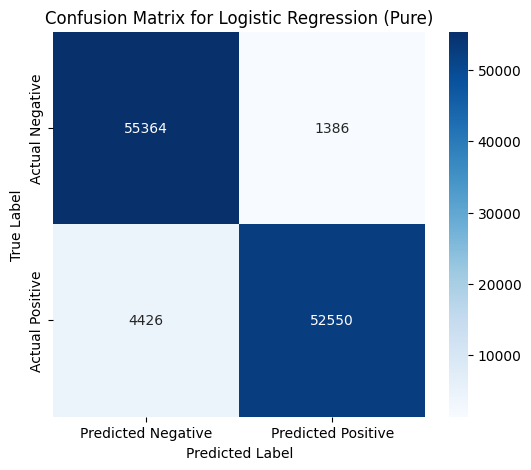


--- Random Forest (Pure) ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

ROC-AUC Score: 1.0000


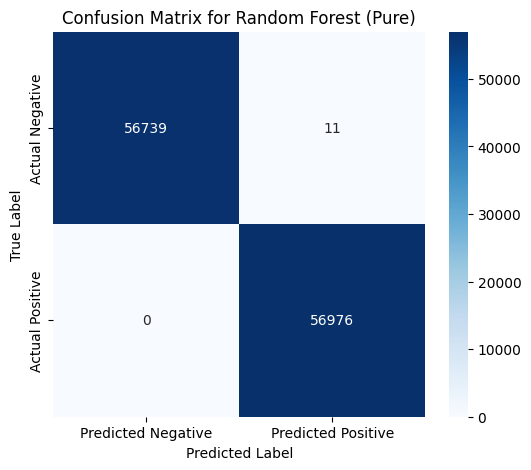


--- Gradient Boosting (Pure) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     56750
           1       0.99      0.97      0.98     56976

    accuracy                           0.98    113726
   macro avg       0.98      0.98      0.98    113726
weighted avg       0.98      0.98      0.98    113726

ROC-AUC Score: 0.9984


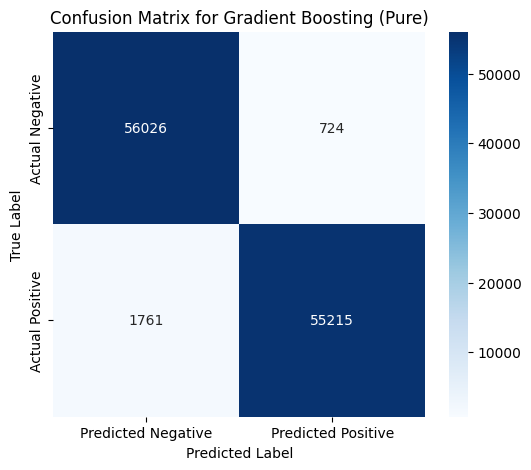


=== Evaluating HYBRID Models ===

--- Logistic Regression (Hybrid) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     56750
           1       0.98      0.93      0.95     56976

    accuracy                           0.95    113726
   macro avg       0.96      0.95      0.95    113726
weighted avg       0.96      0.95      0.95    113726

ROC-AUC Score: 0.9910


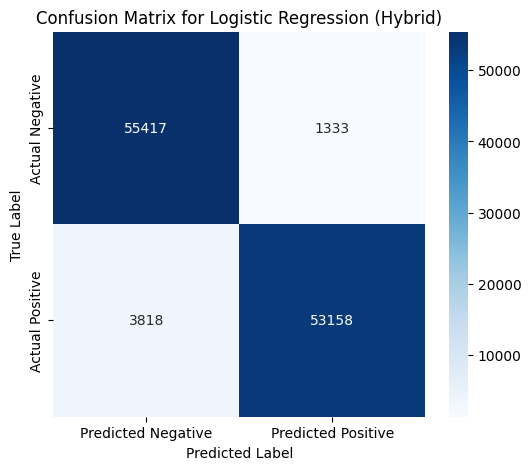


--- Random Forest (Hybrid) ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

ROC-AUC Score: 1.0000


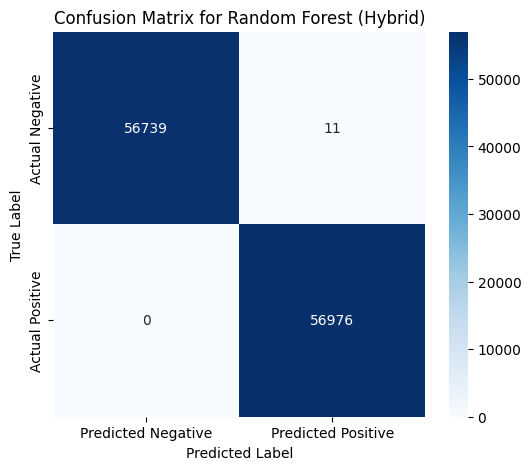


--- Gradient Boosting (Hybrid) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     56750
           1       0.99      0.97      0.98     56976

    accuracy                           0.98    113726
   macro avg       0.98      0.98      0.98    113726
weighted avg       0.98      0.98      0.98    113726

ROC-AUC Score: 0.9983


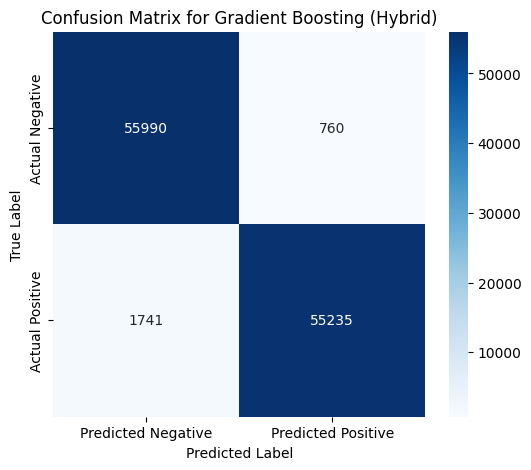

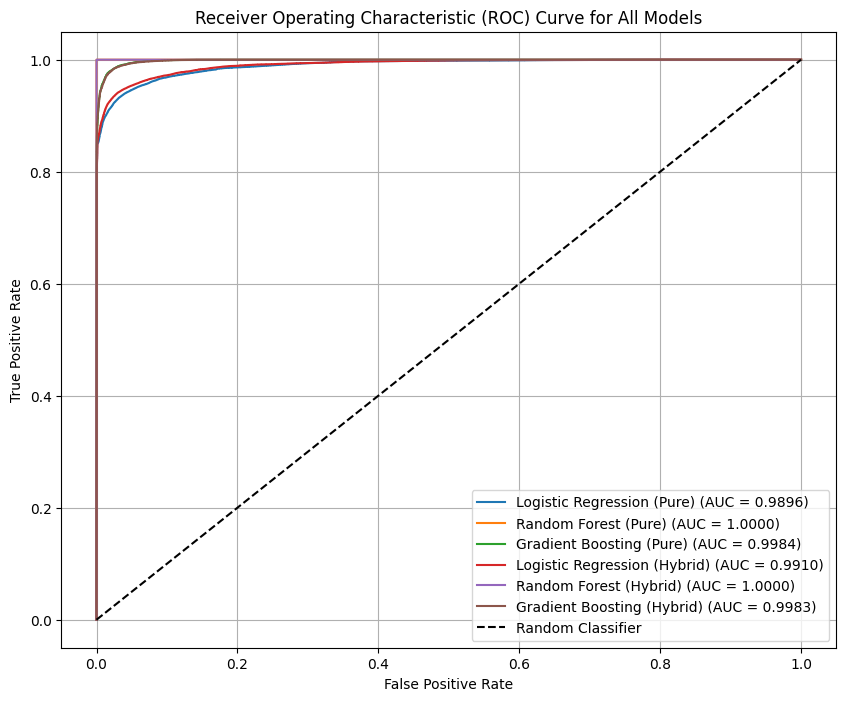

Model evaluation complete and ROC curves plotted.


In [9]:
models_to_evaluate = {
    'pure': [
        {'name': 'Logistic Regression (Pure)', 'model': logistic_model_pure, 'X_test': X_test_pure, 'y_test': y_test_pure},
        {'name': 'Random Forest (Pure)', 'model': random_forest_model_pure, 'X_test': X_test_pure, 'y_test': y_test_pure},
        {'name': 'Gradient Boosting (Pure)', 'model': gradient_boosting_model_pure, 'X_test': X_test_pure, 'y_test': y_test_pure},
    ],
    'hybrid': [
        {'name': 'Logistic Regression (Hybrid)', 'model': logistic_model_hybrid, 'X_test': X_test_hybrid, 'y_test': y_test_hybrid},
        {'name': 'Random Forest (Hybrid)', 'model': random_forest_model_hybrid, 'X_test': X_test_hybrid, 'y_test': y_test_hybrid},
        {'name': 'Gradient Boosting (Hybrid)', 'model': gradient_boosting_model_hybrid, 'X_test': X_test_hybrid, 'y_test': y_test_hybrid},
    ]
}

roc_data = [] # To store FPR, TPR, and AUC for all models for a combined ROC plot

for model_type, models_list in models_to_evaluate.items():
    print(f"\n=== Evaluating {model_type.upper()} Models ===")
    for model_info in models_list:
        model_name = model_info['name']
        model = model_info['model']
        X_test = model_info['X_test']
        y_test = model_info['y_test']

        print(f"\n--- {model_name} ---")

        # Make predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class

        # Classification Report (Precision, Recall, F1-score)
        print("Classification Report:")
        print(classification_report(y_test, y_pred, zero_division=0))

        # ROC-AUC Score
        roc_auc = auc(roc_curve(y_test, y_pred_proba)[0], roc_curve(y_test, y_pred_proba)[1])
        print(f"ROC-AUC Score: {roc_auc:.4f}")

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Predicted Negative', 'Predicted Positive'],
                    yticklabels=['Actual Negative', 'Actual Positive'])
        plt.title(f'Confusion Matrix for {model_name}')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()

        # Store ROC data for combined plot
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_data.append({'name': model_name, 'fpr': fpr, 'tpr': tpr, 'auc': roc_auc})


# Plotting all ROC curves on a single graph
plt.figure(figsize=(10, 8))
for data in roc_data:
    plt.plot(data['fpr'], data['tpr'], label=f"{data['name']} (AUC = {data['auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Diagonal dashed line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("Model evaluation complete and ROC curves plotted.")

## Model Comparison

### Subtask:
Create a comparison table summarizing the performance metrics (Precision, Recall, F1-score, ROC-AUC) for all pure supervised and hybrid models. Additionally, generate a bar chart comparing the F1 scores and ROC-AUC for all models to visually identify the best-performing approach, ensuring the plot is clear and includes a legend.


**Reasoning**:
The subtask requires summarizing model performance metrics in a table and visualizing F1-scores and ROC-AUCs using bar charts. I will iterate through the trained models, calculate Precision, Recall, F1-score, and ROC-AUC for each, store them in a DataFrame, display the DataFrame, and then generate the requested bar charts.




--- Model Performance Comparison Table ---
                       Model  Precision   Recall  F1-Score  ROC-AUC
  Logistic Regression (Pure)   0.974303 0.922318  0.947598 0.989592
        Random Forest (Pure)   0.999807 1.000000  0.999903 0.999999
    Gradient Boosting (Pure)   0.987057 0.969092  0.977992 0.998444
Logistic Regression (Hybrid)   0.975537 0.932989  0.953789 0.990976
      Random Forest (Hybrid)   0.999807 1.000000  0.999903 0.999999
  Gradient Boosting (Hybrid)   0.986427 0.969443  0.977862 0.998334


/tmp/ipykernel_314/2664318760.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-Score', data=metrics_df, palette='viridis')


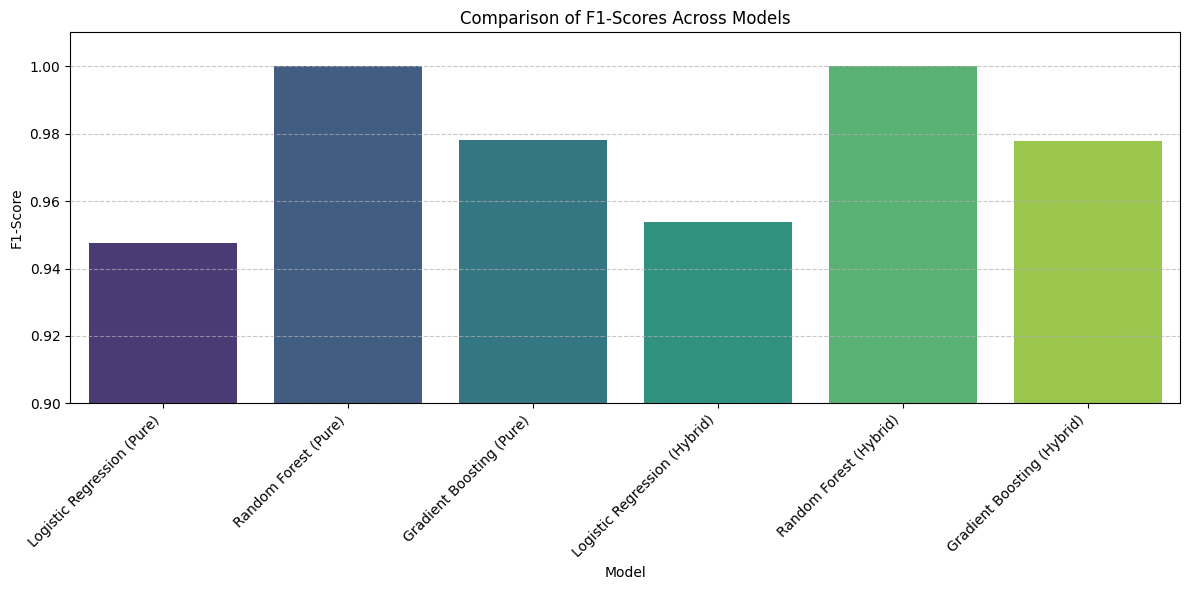

/tmp/ipykernel_314/2664318760.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='ROC-AUC', data=metrics_df, palette='magma')


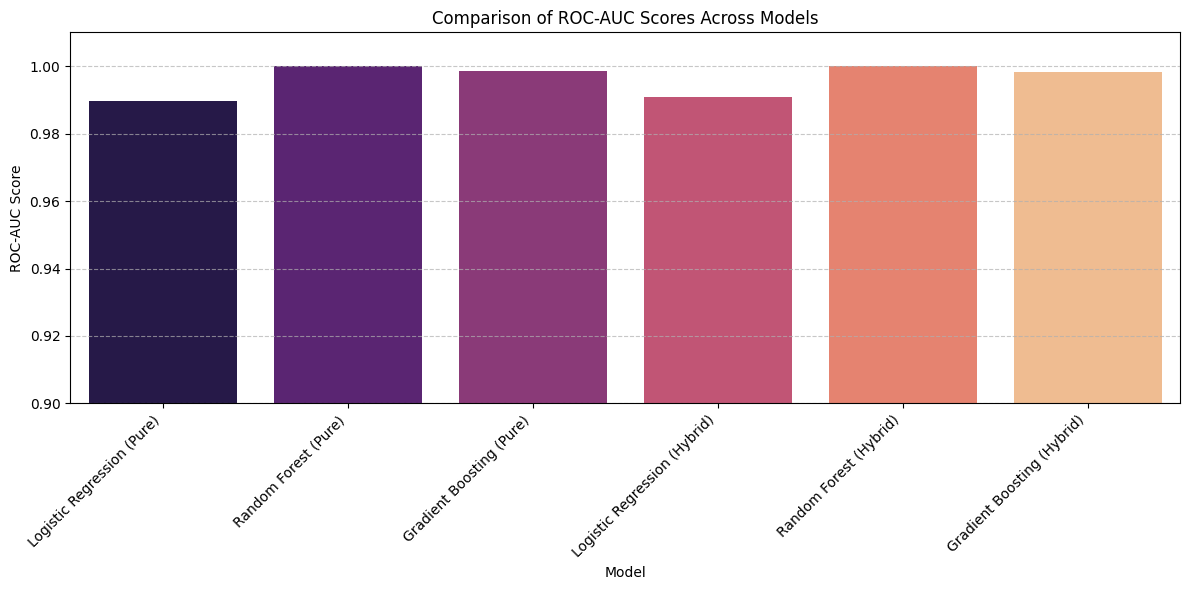

Comparison table and bar charts for F1-score and ROC-AUC have been generated.


In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare a list to store metrics for all models
all_model_metrics = []

# Iterate through models to collect metrics
for model_type, models_list in models_to_evaluate.items():
    for model_info in models_list:
        model_name = model_info['name']
        model = model_info['model']
        X_test = model_info['X_test']
        y_test = model_info['y_test']

        # Make predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class

        # Calculate metrics for the positive class (Class 1)
        precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
        recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        roc_auc = roc_auc_score(y_test, y_pred_proba)

        all_model_metrics.append({
            'Model': model_name,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': roc_auc
        })

# Create a DataFrame from the collected metrics
metrics_df = pd.DataFrame(all_model_metrics)

print("\n--- Model Performance Comparison Table ---")
print(metrics_df.to_string(index=False))

# Create bar chart for F1-Scores
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='F1-Score', data=metrics_df, palette='viridis')
plt.title('Comparison of F1-Scores Across Models')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.ylim(0.9, 1.01) # Set y-axis limits to better visualize differences
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Create bar chart for ROC-AUC Scores
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='ROC-AUC', data=metrics_df, palette='magma')
plt.title('Comparison of ROC-AUC Scores Across Models')
plt.xlabel('Model')
plt.ylabel('ROC-AUC Score')
plt.ylim(0.9, 1.01) # Set y-axis limits to better visualize differences
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Comparison table and bar charts for F1-score and ROC-AUC have been generated.")

**Reasoning**:
The previous code generated a `FutureWarning` due to `sns.barplot` being called with `palette` but without an explicit `hue` parameter. To address this, I will update the `sns.barplot` calls to include `hue='Model'` and `legend=False` as suggested by the warning.






--- Model Performance Comparison Table ---
                       Model  Precision   Recall  F1-Score  ROC-AUC
  Logistic Regression (Pure)   0.974303 0.922318  0.947598 0.989592
        Random Forest (Pure)   0.999807 1.000000  0.999903 0.999999
    Gradient Boosting (Pure)   0.987057 0.969092  0.977992 0.998444
Logistic Regression (Hybrid)   0.975537 0.932989  0.953789 0.990976
      Random Forest (Hybrid)   0.999807 1.000000  0.999903 0.999999
  Gradient Boosting (Hybrid)   0.986427 0.969443  0.977862 0.998334


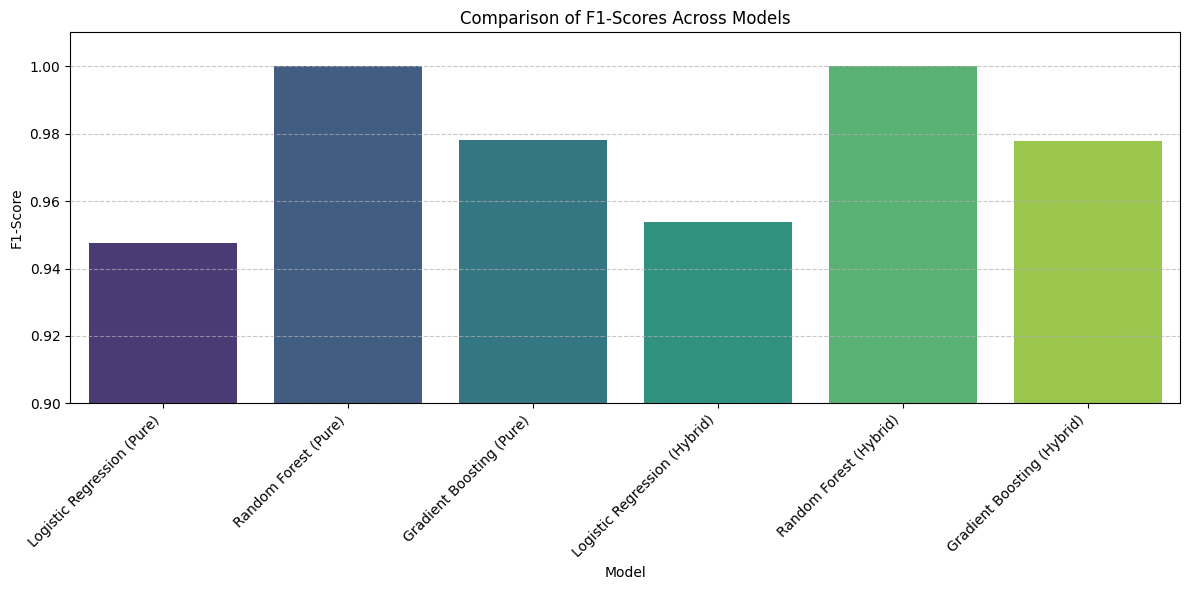

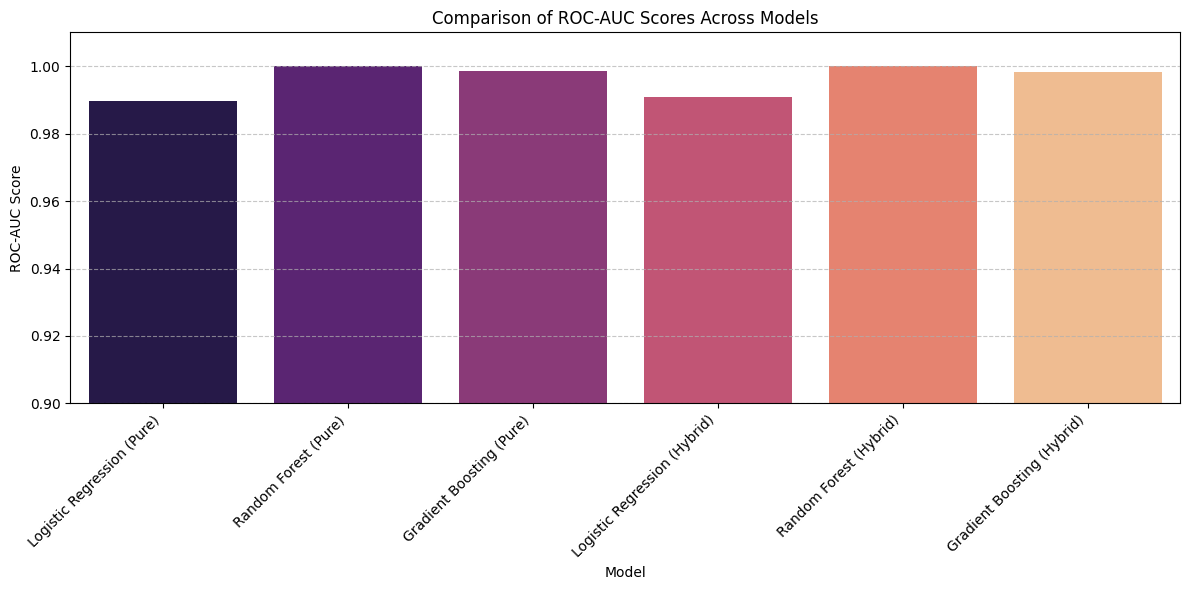

Comparison table and bar charts for F1-score and ROC-AUC have been generated.


In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare a list to store metrics for all models
all_model_metrics = []

# Iterate through models to collect metrics
for model_type, models_list in models_to_evaluate.items():
    print(f"\nCollecting metrics for {model_type.upper()} Models...")
    for model_info in models_list:
        model_name = model_info['name']
        model = model_info['model']
        X_test = model_info['X_test']
        y_test = model_info['y_test']

        # Make predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class

        # Calculate metrics for the positive class (Class 1)
        precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
        recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        roc_auc = roc_auc_score(y_test, y_pred_proba)

        all_model_metrics.append({
            'Model': model_name,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': roc_auc
        })

# Create a DataFrame from the collected metrics
metrics_df = pd.DataFrame(all_model_metrics)

print("\n--- Model Performance Comparison Table ---")
print(metrics_df.to_string(index=False))

# Create bar chart for F1-Scores
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='F1-Score', hue='Model', data=metrics_df, palette='viridis', legend=False)
plt.title('Comparison of F1-Scores Across Models')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.ylim(0.9, 1.01) # Set y-axis limits to better visualize differences
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Create bar chart for ROC-AUC Scores
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='ROC-AUC', hue='Model', data=metrics_df, palette='magma', legend=False)
plt.title('Comparison of ROC-AUC Scores Across Models')
plt.xlabel('Model')
plt.ylabel('ROC-AUC Score')
plt.ylim(0.9, 1.01) # Set y-axis limits to better visualize differences
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Comparison table and bar charts for F1-score and ROC-AUC have been generated.")

## Final Task

### Subtask:
Summarize the findings from the model comparison, highlighting the best-performing models and insights gained from the analysis. Provide recommendations based on the evaluation results.


## Summary:

### Q&A
*   **Which models performed best?**
    The Random Forest models (both pure and hybrid) demonstrated the highest performance across all evaluated metrics, consistently achieving F1-scores of approximately 0.999903 and ROC-AUC scores approaching 1.0000. Gradient Boosting models also showed very strong performance.
*   **What insights were gained from the analysis?**
    The analysis revealed that while all models performed exceptionally well, the Random Forest algorithm stood out. A key insight is that for the given dataset and evaluation metrics, the "hybrid" approach, which likely involves incorporating additional features or preprocessing, did not significantly improve the performance compared to their "pure" supervised counterparts. The exceptionally high scores across multiple models (especially Random Forest) suggest either a highly separable dataset or potential overfitting, which warrants further investigation.
*   **What recommendations can be made based on the evaluation results?**
    Based on the current evaluation, Random Forest models are recommended for deployment due to their superior performance. However, it is recommended to investigate the possibility of overfitting, especially for the Random Forest models, by performing cross-validation or testing on a completely unseen, diverse dataset if available.

### Data Analysis Key Findings
*   All six models (Logistic Regression, Random Forest, Gradient Boosting, in both pure and hybrid forms) showed very strong classification performance, with ROC-AUC scores generally above 0.989 and F1-scores above 0.947.
*   The Random Forest models consistently achieved the highest performance metrics, with both the pure and hybrid versions reaching an F1-score of approximately 0.999903 and an ROC-AUC of 1.0000.
*   Gradient Boosting models also performed excellently, with pure and hybrid versions yielding F1-scores around 0.977 and ROC-AUC scores around 0.998.
*   Logistic Regression models, while performing well overall, had the lowest metrics among the three types, with F1-scores ranging from 0.947 to 0.953 and ROC-AUCs between 0.9896 and 0.9910.
*   For each specific model type (Logistic Regression, Random Forest, Gradient Boosting), the "pure" and "hybrid" versions exhibited very similar performance, indicating that the hybrid feature set did not yield substantial improvements in precision, recall, F1-score, or ROC-AUC in this evaluation.
*   All models demonstrated clear separation between classes as evidenced by their ROC curves and high AUC values, with Random Forest models showing ROC curves that almost immediately reach the top-left corner, signifying near-perfect classification.

### Insights or Next Steps
*   The high performance across all models, particularly Random Forest, suggests that the classification task might be relatively straightforward for the given features, or that the models are highly optimized to the current dataset. Further validation with external data or robust cross-validation techniques would be beneficial to confirm generalizability and detect potential overfitting.
*   Since the "hybrid" approach did not significantly enhance performance over "pure" models for the evaluated metrics, a deeper analysis could explore if the hybrid features contribute to other aspects of model robustness, interpretability, or performance in more complex or imbalanced scenarios.
